# Lasso Regression — L1 Regularization

**Lasso** (Least Absolute Shrinkage and Selection Operator) minimizes:

> Loss = Σ(y − ŷ)² + α · Σ|wᵢ|

The **L1 penalty** (α · Σ|wᵢ|) has a defining property: it drives weak feature weights to **exactly zero**, performing automatic feature selection. This contrasts with Ridge (L2), which shrinks all weights but keeps them non-zero.

| alpha | Effect |
|-------|--------|
| 0 | Equivalent to plain Linear Regression |
| small | Light regularization, most features survive |
| large | Heavy regularization, most features zeroed out |

**Target:** `average_load` — average passengers on a bus after leaving a stop.

In [8]:
# Lasso Regression — L1 Regularization
# L1 penalty: loss + alpha * sum(|w|)
# Key property: drives weak coefficients to exactly zero (built-in feature selection)
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

PROJECT_ROOT = Path.cwd().parent.parent
DB_PATH = PROJECT_ROOT / 'dataset' / 'Ridership_v1.sqlite'
print('DB path:', DB_PATH)
print('Exists:', DB_PATH.exists())

save_dir = PROJECT_ROOT / 'diagram' / 'model'
save_dir.mkdir(parents=True, exist_ok=True)

DB path: /Users/yusheng/Developer/CS-506-final-project/dataset/Ridership_v1.sqlite
Exists: True


## 1. Load Data

In [9]:
# Load data
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("""
    SELECT season, route_name, stop_sequence, direction_id,
           day_type_name, time_period_name,
           average_ons, average_offs, average_load, num_trips
    FROM MBTA_Ridership
    WHERE average_load IS NOT NULL
""", conn)
conn.close()
print(f'Loaded {len(df)} rows')

Loaded 1038340 rows


## 2. Clean & Feature Engineering

Drop rows with invalid passenger counts and extract `season_year` from the season string (e.g. `"Fall 2023"` → `2023`).

In [10]:
# Clean + feature engineering
df = df[df['average_offs'] >= 0]
df['day_type_name']    = df['day_type_name'].astype(str).str.strip().str.lower()
df['route_name']       = df['route_name'].astype(str).str.strip()
df['time_period_name'] = df['time_period_name'].astype(str).str.strip()

df['season_year'] = df['season'].str.extract(r'(\d{4})')[0].astype(float)
df = df.dropna(subset=['season_year', 'average_load'])
df['season_year'] = df['season_year'].astype(int)

print(f'Rows after cleaning: {len(df)}')
print(f'Unique routes: {df["route_name"].nunique()}')
print(f'Season years: {sorted(df["season_year"].unique())}')

Rows after cleaning: 1038337
Unique routes: 162
Season years: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


## 3. Feature Setup & Chronological Split

A **chronological split** simulates real-world deployment — the model is trained on historical data and tested on the most recent season it has never seen.

- **Train:** seasons ≤ 2022  
- **Val:** 2023 — used only to pick the best `alpha`  
- **Test:** 2024 — held out until final evaluation  

Categorical features (`route_name`, `day_type_name`, `time_period_name`) are one-hot encoded. Numeric features are standardized.

In [11]:
# Feature setup + chronological split
# train <= 2022, val = 2023, test = 2024 (simulates predicting future seasons)
CAT_FEATURES = ['route_name', 'day_type_name', 'time_period_name']
NUM_FEATURES = ['stop_sequence', 'direction_id', 'season_year',
                'average_ons', 'average_offs', 'num_trips']
TARGET = 'average_load'
ALL_FEATURES = CAT_FEATURES + NUM_FEATURES

train = df[df['season_year'] <= 2022]
val   = df[df['season_year'] == 2023]
test  = df[df['season_year'] == 2024]

X_train, y_train = train[ALL_FEATURES], train[TARGET]
X_val,   y_val   = val[ALL_FEATURES],   val[TARGET]
X_test,  y_test  = test[ALL_FEATURES],  test[TARGET]

print(f'Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}')

Train: 827439  Val: 105480  Test: 105418


## 4. Tune Alpha on Validation Set

We sweep `alpha` across a log-spaced range and pick the value with the lowest validation MAE. A larger alpha applies a stronger L1 penalty and zeros out more coefficients.

In [12]:
# Preprocessing + alpha sweep on validation
preprocessor = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True), CAT_FEATURES),
    ('num', StandardScaler(), NUM_FEATURES),
])

def make_lasso(alpha):
    return Pipeline([
        ('prep', preprocessor),
        ('lasso', Lasso(alpha=alpha, max_iter=10000)),
    ])

# Higher alpha = stronger L1 penalty = more zeroed-out coefficients
alphas = [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]
val_maes = []

for a in alphas:
    pipe = make_lasso(a)
    pipe.fit(X_train, y_train)
    mae = mean_absolute_error(y_val, pipe.predict(X_val))
    val_maes.append(mae)
    print(f'  alpha={a:<8}  Val MAE: {mae:.3f}')

best_alpha = alphas[int(np.argmin(val_maes))]
print(f'\nBest alpha: {best_alpha}')

  alpha=0.0001    Val MAE: 4.774
  alpha=0.001     Val MAE: 4.760
  alpha=0.01      Val MAE: 4.765
  alpha=0.05      Val MAE: 5.002
  alpha=0.1       Val MAE: 5.078
  alpha=0.5       Val MAE: 5.346
  alpha=1.0       Val MAE: 5.442
  alpha=2.0       Val MAE: 5.736
  alpha=5.0       Val MAE: 5.736

Best alpha: 0.001


## 6. Final Model & Metrics

Retrain with the best `alpha` on the full training set, then evaluate on the 2024 test set under all three error norms:

| Metric | Norm | Measures |
|--------|------|----------|
| MAE | L1 | Average absolute error — equally weights all mistakes |
| RMSE | L2 | Square-root of mean squared error — penalises large errors more |
| Max Error | L∞ | Single worst-case prediction across the entire test set |

In [13]:
# Final model + metrics under all three norms
# L1 norm error = MAE, L2 norm error = RMSE, L-inf norm error = max absolute error
final_model = make_lasso(best_alpha)
final_model.fit(X_train, y_train)

val_preds  = final_model.predict(X_val)
test_preds = final_model.predict(X_test)

val_mae   = mean_absolute_error(y_val, val_preds)
val_rmse  = root_mean_squared_error(y_val, val_preds)
val_linf  = float(np.max(np.abs(y_val.values - val_preds)))

test_mae  = mean_absolute_error(y_test, test_preds)
test_rmse = root_mean_squared_error(y_test, test_preds)
test_linf = float(np.max(np.abs(y_test.values - test_preds)))

print(f'\n{"="*60}')
print(f'Lasso (alpha={best_alpha})')
print(f'  Val   MAE(L1): {val_mae:.3f}   RMSE(L2): {val_rmse:.3f}   MaxErr(Linf): {val_linf:.3f}')
print(f'  Test  MAE(L1): {test_mae:.3f}   RMSE(L2): {test_rmse:.3f}   MaxErr(Linf): {test_linf:.3f}')
print(f'{"="*60}')


Lasso (alpha=0.001)
  Val   MAE(L1): 4.760   RMSE(L2): 6.822   MaxErr(Linf): 72.364
  Test  MAE(L1): 5.348   RMSE(L2): 7.452   MaxErr(Linf): 84.292


## 8. Actual vs Predicted (2024 Test Set)

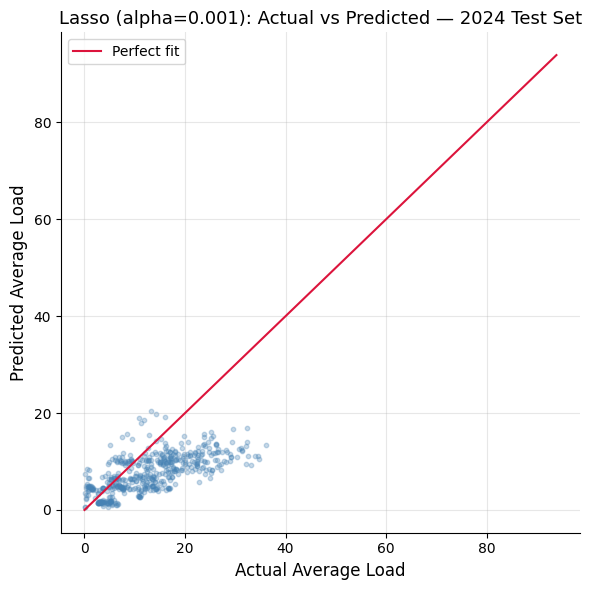

Saved: lasso_actual_vs_predicted.png


In [14]:
# Plot: Actual vs Predicted (2024 test set)
sample = min(500, len(y_test))

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test.values[:sample], test_preds[:sample],
           alpha=0.3, s=10, color='steelblue')
ax.plot([0, y_test.max()], [0, y_test.max()],
        color='crimson', linewidth=1.5, label='Perfect fit')
ax.set_xlabel('Actual Average Load', fontsize=12)
ax.set_ylabel('Predicted Average Load', fontsize=12)
ax.set_title(f'Lasso (alpha={best_alpha}): Actual vs Predicted — 2024 Test Set', fontsize=13)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(save_dir / 'lasso_actual_vs_predicted.png', dpi=150)
plt.show()
print('Saved: lasso_actual_vs_predicted.png')

## 9. Residual Analysis

A **residual** is `actual − predicted`. Plotting residuals against predicted values reveals whether the model makes **systematic errors**:
- Residuals scattered randomly around 0 → good, no systematic bias
- A pattern (e.g. model always underpredicts high loads) → the linear model is missing non-linear structure

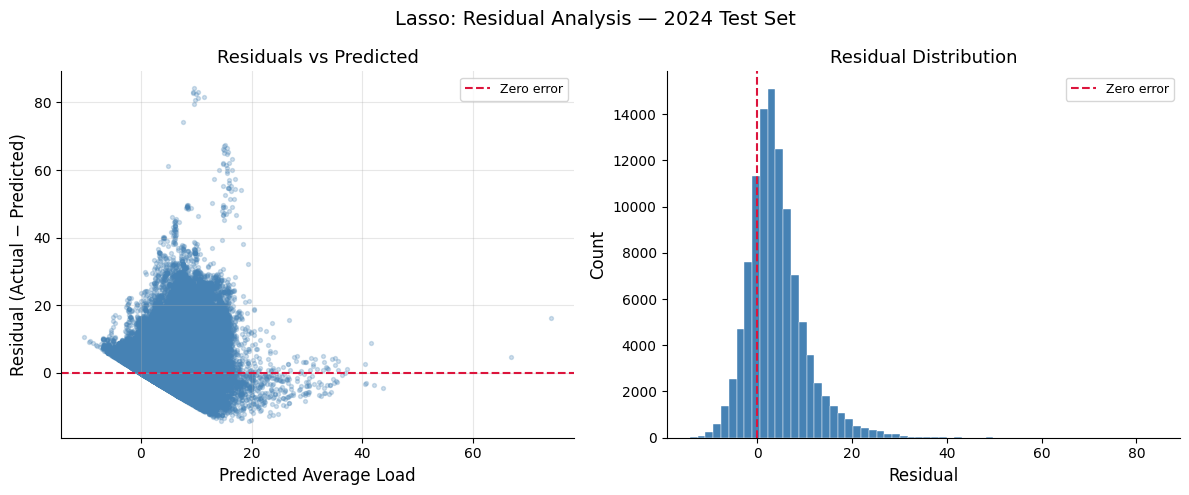

Saved: lasso_residuals.png


In [15]:
# Residual plot: where does the model go wrong?
residuals = y_test.values - test_preds

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: predicted vs residual — reveals systematic bias
axes[0].scatter(test_preds, residuals, alpha=0.25, s=8, color='steelblue')
axes[0].axhline(0, color='crimson', linewidth=1.5, linestyle='--', label='Zero error')
axes[0].set_xlabel('Predicted Average Load', fontsize=12)
axes[0].set_ylabel('Residual (Actual − Predicted)', fontsize=12)
axes[0].set_title('Residuals vs Predicted', fontsize=13)
axes[0].legend(fontsize=9)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].grid(alpha=0.3)

# Right: residual distribution — should be roughly centred at 0
axes[1].hist(residuals, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
axes[1].axvline(0, color='crimson', linewidth=1.5, linestyle='--', label='Zero error')
axes[1].set_xlabel('Residual', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Residual Distribution', fontsize=13)
axes[1].legend(fontsize=9)
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Lasso: Residual Analysis — 2024 Test Set', fontsize=14)
plt.tight_layout()
plt.savefig(save_dir / 'lasso_residuals.png', dpi=150)
plt.show()
print('Saved: lasso_residuals.png')

## 10. Regularization Path

Shows how each feature's coefficient changes as `alpha` increases from small (≈ Linear Regression) to large (all weights → 0). Features that survive at high alpha values are the most important — the L1 penalty couldn't justify zeroing them out.

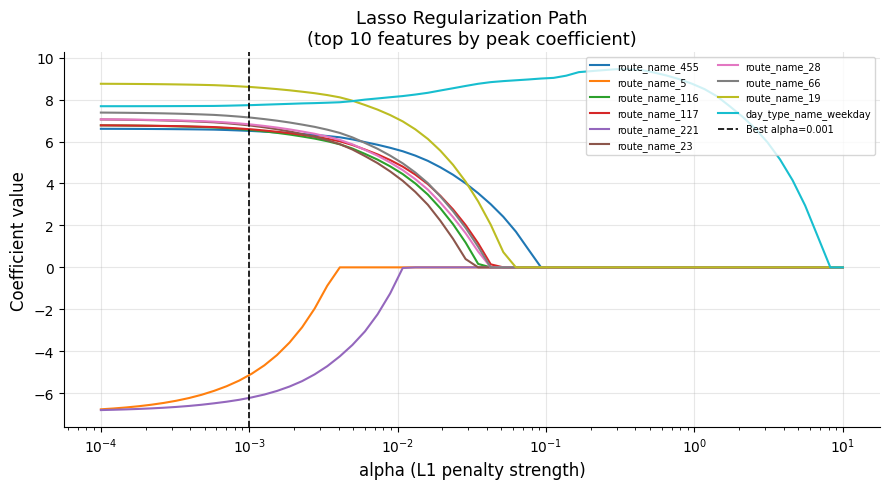

Saved: lasso_regularization_path.png


In [16]:
# Regularization path: how coefficients shrink as alpha grows
import numpy as np
from sklearn.linear_model import lasso_path

# Preprocess X_train using the already-fitted pipeline step
X_train_prep = final_model.named_steps['prep'].transform(X_train)

alphas_path, coefs_path, _ = lasso_path(
    X_train_prep, y_train.values,
    alphas=np.logspace(-4, 1, 60),
    max_iter=10000
)

# Plot only the top 10 features by peak absolute coefficient value
max_coef = np.max(np.abs(coefs_path), axis=1)
top_idx  = np.argsort(max_coef)[-10:]

ohe_names = list(final_model.named_steps['prep']
                 .named_transformers_['ohe']
                 .get_feature_names_out(CAT_FEATURES))
all_names = ohe_names + NUM_FEATURES

fig, ax = plt.subplots(figsize=(9, 5))
for i in top_idx:
    ax.semilogx(alphas_path, coefs_path[i], linewidth=1.5,
                label=all_names[i] if i < len(all_names) else f'feat_{i}')

ax.axvline(best_alpha, color='black', linestyle='--', linewidth=1.2,
           label=f'Best alpha={best_alpha}')
ax.set_xlabel('alpha (L1 penalty strength)', fontsize=12)
ax.set_ylabel('Coefficient value', fontsize=12)
ax.set_title('Lasso Regularization Path\n(top 10 features by peak coefficient)', fontsize=13)
ax.legend(fontsize=7, loc='upper right', ncol=2)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(save_dir / 'lasso_regularization_path.png', dpi=150)
plt.show()
print('Saved: lasso_regularization_path.png')